In [1]:
import torch.nn.functional as F
import torch.nn as nn
import torch
import time
import matplotlib.pyplot as plt
import re
from collections import Counter
from datasets import load_dataset
from torch.utils.data import DataLoader
import tiktoken


In [2]:


class MLP(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class, hidden_dim):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=True)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_class)

        # initialize the weights
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        nn.init.xavier_uniform_(self.fc1.weight)
        self.fc1.bias.data.zero_()
        nn.init.xavier_uniform_(self.fc2.weight)
        self.fc2.bias.data.zero_()

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        hidden = F.relu(self.fc1(embedded))
        return self.fc2(hidden)




In [3]:
class SLP(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=True)
        self.fc = nn.Linear(embed_dim, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        return self.fc(embedded)

In [4]:


def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_acc, total_count = 0, 0

    for idx, (label, text, offsets) in enumerate(dataloader):
        label, text, offsets = label.to(device), text.to(device), offsets.to(device)
        optimizer.zero_grad()
        predicted_label = model(text, offsets)
        loss = criterion(predicted_label, label)
        loss.backward()

        non_sparse_params = [p for p in model.parameters() if p.grad is not None and not p.grad.is_sparse]
        if len(non_sparse_params) > 0:
            torch.nn.utils.clip_grad_norm_(non_sparse_params, 0.1)

        optimizer.step()

        total_acc += (predicted_label.argmax(1) == label).sum().item()
        total_count += label.size(0)

    return total_acc / total_count

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_acc, total_count = 0, 0

    with torch.no_grad():
        for label, text, offsets in dataloader:
            label, text, offsets = label.to(device), text.to(device), offsets.to(device)
            predicted_label = model(text, offsets)
            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)

    return total_acc / total_count

In [5]:



dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

def basic_tokenizer(text):
    return re.findall(r'\w+', text.lower())

def build_vocab(datasets, min_freq=1):
    counter = Counter()
    for item in datasets:
        tokens = basic_tokenizer(item['text'])
        counter.update(tokens)

    word2idx = {'<pad>': 0, '<unk>': 1}

    for word, count in counter.items():
        if count >= min_freq:
            word2idx[word] = len(word2idx)

    return word2idx
vocab = build_vocab(dataset['train'])
vocab_size = len(vocab)
print(f"Vocab Size: {vocab_size}")


def collate_batch(batch):
    label_list, text_list, offsets = [], [], [0]

    for item in batch:
        label_list.append(item['label'])
        tokens = basic_tokenizer(item['text'])
        token_ids = [vocab.get(word, vocab['<unk>']) for word in tokens]
        if len(token_ids) == 0:
            token_ids = [vocab['<unk>']]

        processed_text = torch.tensor(token_ids, dtype=torch.int64)
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))

    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)

    return label_list, text_list, offsets

BATCH_SIZE = 64
train_dataloader = DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
valid_dataloader = DataLoader(dataset['validation'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_dataloader = DataLoader(dataset['test'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Vocab Size: 43397


In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [7]:
#use different tokenizer method

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

tokenizer = tiktoken.get_encoding("o200k_base")

vocab_size = tokenizer.n_vocab
print(f"O200k_base Vocab Size: {vocab_size}")

def collate_batch(batch):
    label_list, text_list, offsets = [], [], [0]

    for item in batch:
        label_list.append(item['label'])

        token_ids = tokenizer.encode(item['text'])


        if len(token_ids) == 0:
            token_ids = [0]

        processed_text = torch.tensor(token_ids, dtype=torch.int64)
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))

    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)

    return label_list, text_list, offsets

BATCH_SIZE = 64
train_dataloader_o = DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
valid_dataloader_o = DataLoader(dataset['validation'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_dataloader_o = DataLoader(dataset['test'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

O200k_base Vocab Size: 200019


In [8]:

VOCAB_SIZE = len(vocab)
EMBED_DIM = 64
NUM_CLASS = 3
HIDDEN_DIM = 100


model_MLP = MLP(VOCAB_SIZE, EMBED_DIM, NUM_CLASS, HIDDEN_DIM)
print(model_MLP)

MLP(
  (embedding): EmbeddingBag(43397, 64, mode='mean')
  (fc1): Linear(in_features=64, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=3, bias=True)
)


In [9]:
model_SLP = SLP(VOCAB_SIZE, EMBED_DIM, NUM_CLASS)
print(model_SLP)

SLP(
  (embedding): EmbeddingBag(43397, 64, mode='mean')
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [10]:

experiment_results = {}
hidden_dims = [100, 500]
EPOCHS = 10
EMBED_DIM = 64
LR = 2.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.CrossEntropyLoss()
print("--- Training SLP Baseline ---")

slp_model = SLP(vocab_size, embed_dim=EMBED_DIM, num_class=NUM_CLASS).to(device)
slp_optimizer = torch.optim.SGD(slp_model.parameters(), lr=LR)

slp_train_acc_history = []
slp_test_acc_history = []

for epoch in range(1, EPOCHS + 1):
    train_acc = train_epoch(slp_model, train_dataloader, slp_optimizer, criterion, device)
    test_acc = evaluate(slp_model, test_dataloader, criterion, device)

    slp_train_acc_history.append(train_acc)
    slp_test_acc_history.append(test_acc)
    print(f"Epoch: {epoch:2d}, Train Acc: {train_acc:.4f}, test Acc: {test_acc:.4f}")

experiment_results['SLP'] = {
    'train': slp_train_acc_history,
    'test': slp_test_acc_history
}

for h_dim in hidden_dims:
    print(f"\n--- Training MLP with Hidden Dim: {h_dim} ---")
    mlp_model = MLP(vocab_size, embed_dim=EMBED_DIM, num_class=NUM_CLASS, hidden_dim=h_dim).to(device)
    mlp_optimizer = torch.optim.SGD(mlp_model.parameters(), lr=LR)

    mlp_train_acc_history = []
    mlp_test_acc_history = []

    for epoch in range(1, EPOCHS + 1):
        train_acc = train_epoch(mlp_model, train_dataloader, mlp_optimizer, criterion, device)
        test_acc = evaluate(mlp_model, test_dataloader, criterion, device)

        mlp_train_acc_history.append(train_acc)
        mlp_test_acc_history.append(test_acc)
        print(f"Epoch: {epoch:2d}, Train Acc: {train_acc:.4f}, test Acc: {test_acc:.4f}")

    experiment_results[f'MLP_{h_dim}'] = {
        'train': mlp_train_acc_history,
        'test': mlp_test_acc_history
    }

print("\n---Finish ---")

--- Training SLP Baseline ---
Epoch:  1, Train Acc: 0.5276, test Acc: 0.4459
Epoch:  2, Train Acc: 0.6009, test Acc: 0.3865
Epoch:  3, Train Acc: 0.6371, test Acc: 0.4644
Epoch:  4, Train Acc: 0.6605, test Acc: 0.5101
Epoch:  5, Train Acc: 0.6769, test Acc: 0.4760
Epoch:  6, Train Acc: 0.6919, test Acc: 0.4631
Epoch:  7, Train Acc: 0.7045, test Acc: 0.4763
Epoch:  8, Train Acc: 0.7167, test Acc: 0.4324
Epoch:  9, Train Acc: 0.7262, test Acc: 0.4937
Epoch: 10, Train Acc: 0.7337, test Acc: 0.5122

--- Training MLP with Hidden Dim: 100 ---
Epoch:  1, Train Acc: 0.5285, test Acc: 0.4475
Epoch:  2, Train Acc: 0.6034, test Acc: 0.5318
Epoch:  3, Train Acc: 0.6369, test Acc: 0.5001
Epoch:  4, Train Acc: 0.6609, test Acc: 0.4757
Epoch:  5, Train Acc: 0.6811, test Acc: 0.5331
Epoch:  6, Train Acc: 0.6970, test Acc: 0.5139
Epoch:  7, Train Acc: 0.7091, test Acc: 0.5118
Epoch:  8, Train Acc: 0.7190, test Acc: 0.5544
Epoch:  9, Train Acc: 0.7320, test Acc: 0.5596
Epoch: 10, Train Acc: 0.7432, test

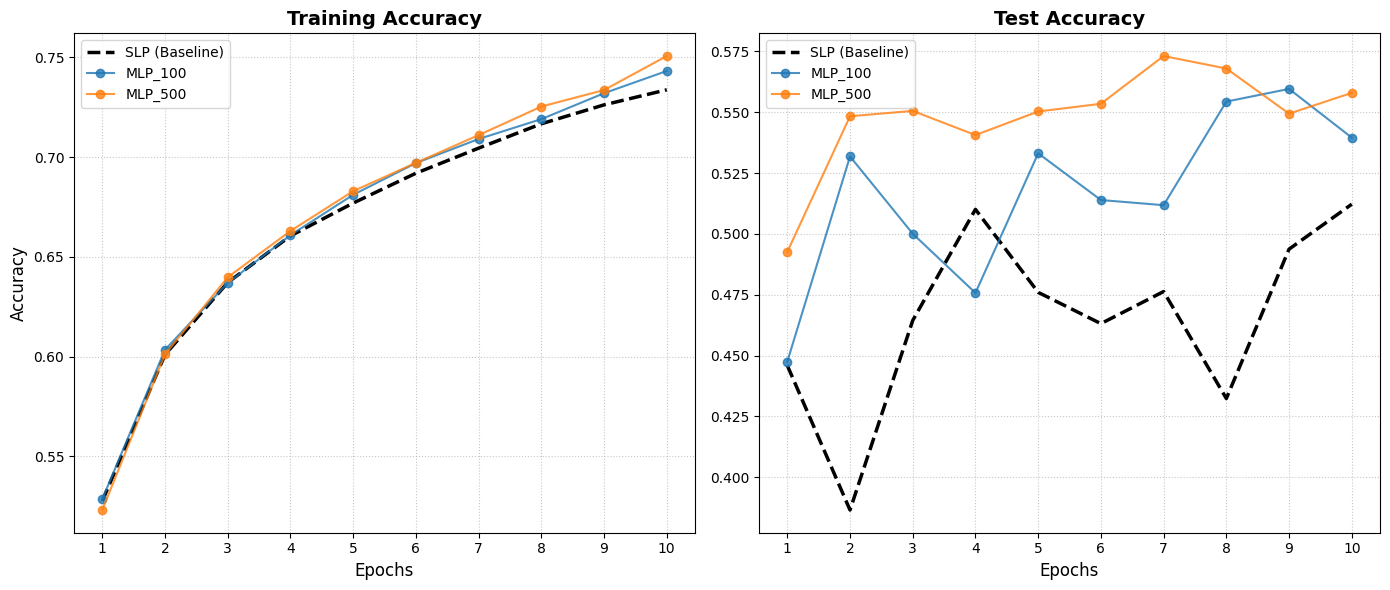

In [11]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
epochs_range = range(1, EPOCHS + 1)


for model_name, metrics in experiment_results.items():
    train_accs = metrics['train']
    test_accs = metrics['test']

    if model_name == 'SLP':
        ax1.plot(epochs_range, train_accs, label=f"{model_name} (Baseline)", linestyle='--', color='black', linewidth=2.5)
        ax2.plot(epochs_range, test_accs, label=f"{model_name} (Baseline)", linestyle='--', color='black', linewidth=2.5)
    else:
        ax1.plot(epochs_range, train_accs, label=model_name, marker='o', alpha=0.8)
        ax2.plot(epochs_range, test_accs, label=model_name, marker='o', alpha=0.8)

ax1.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

ax2.set_title('Test Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()

plt.show()

In [15]:


idx2word = {idx: word for word, idx in vocab.items()}
def get_misclassified_examples(model, dataloader, num_examples=5):
    model.eval()
    misclassified = []

    label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

    with torch.no_grad():
        for label, text, offsets in dataloader:
            predictions = model(text, offsets)
            pred_labels = predictions.argmax(1)

            errors = (pred_labels != label).nonzero(as_tuple=True)[0]

            for idx in errors:

                start_idx = offsets[idx]
                end_idx = offsets[idx+1] if idx+1 < len(offsets) else len(text)
                token_ids = text[start_idx:end_idx].tolist()

                words = [idx2word.get(t_id, '<unk>') for t_id in token_ids]
                original_text = " ".join(words)

                misclassified.append({
                    'text': original_text,
                    'true_label': label_map[label[idx].item()],
                    'pred_label': label_map[pred_labels[idx].item()]
                })

                if len(misclassified) >= num_examples:
                    return misclassified
    return misclassified

best_mlp_model = mlp_model
errors = get_misclassified_examples(best_mlp_model, test_dataloader, num_examples=5)


for i, err in enumerate(errors, 1):
    print(f"\nExample {i}:")
    print(f"Text: {err['text']}")
    print(f"True Label: {err['true_label']}")
    print(f"Predicted Label: {err['pred_label']}")


Example 1:
Text: user user that s coming but i think the victims are going to be medicaid <unk>
True Label: Neutral
Predicted Label: Positive

Example 2:
Text: i think i may be finally in with the in crowd <unk> <unk> user
True Label: Positive
Predicted Label: Neutral

Example 3:
Text: user wow first hugo <unk> and now <unk> castro danny glover michael moore oliver stone and sean penn are running out of heroes
True Label: Negative
Predicted Label: Positive

Example 4:
Text: twitter s <unk> shows heartfelt gratitude to potus
True Label: Positive
Predicted Label: Neutral

Example 5:
Text: all <unk> and fracking all around australia is to cease and mining entities held accountable sign the petition
True Label: Neutral
Predicted Label: Positive


##Diff tokenizer method

In [13]:


experiment_results = {}
hidden_dims = [100, 500]
EPOCHS = 10
EMBED_DIM = 64
LR = 2.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.CrossEntropyLoss()
print("--- Training SLP Baseline ---")

slp_model = SLP(vocab_size, embed_dim=EMBED_DIM, num_class=NUM_CLASS).to(device)
slp_optimizer = torch.optim.SGD(slp_model.parameters(), lr=LR)

slp_train_acc_history = []
slp_test_acc_history = []

for epoch in range(1, EPOCHS + 1):
    train_acc = train_epoch(slp_model, train_dataloader_o, slp_optimizer, criterion, device)
    test_acc = evaluate(slp_model, test_dataloader_o, criterion, device)

    slp_train_acc_history.append(train_acc)
    slp_test_acc_history.append(test_acc)
    print(f"Epoch: {epoch:2d}, Train Acc: {train_acc:.4f}, test Acc: {test_acc:.4f}")

experiment_results['SLP'] = {
    'train': slp_train_acc_history,
    'test': slp_test_acc_history
}

for h_dim in hidden_dims:
    print(f"\n--- Training MLP with Hidden Dim: {h_dim} ---")
    mlp_model = MLP(vocab_size, embed_dim=EMBED_DIM, num_class=NUM_CLASS, hidden_dim=h_dim).to(device)
    mlp_optimizer = torch.optim.SGD(mlp_model.parameters(), lr=LR)

    mlp_train_acc_history = []
    mlp_test_acc_history = []

    for epoch in range(1, EPOCHS + 1):
        train_acc = train_epoch(mlp_model, train_dataloader_o, mlp_optimizer, criterion, device)
        test_acc = evaluate(mlp_model, test_dataloader_o, criterion, device)

        mlp_train_acc_history.append(train_acc)
        mlp_test_acc_history.append(test_acc)
        print(f"Epoch: {epoch:2d}, Train Acc: {train_acc:.4f}, test Acc: {test_acc:.4f}")

    experiment_results[f'MLP_{h_dim}'] = {
        'train': mlp_train_acc_history,
        'test': mlp_test_acc_history
    }

print("\n---Finish ---")

--- Training SLP Baseline ---
Epoch:  1, Train Acc: 0.5385, test Acc: 0.4967
Epoch:  2, Train Acc: 0.5958, test Acc: 0.4825
Epoch:  3, Train Acc: 0.6258, test Acc: 0.5274
Epoch:  4, Train Acc: 0.6517, test Acc: 0.5449
Epoch:  5, Train Acc: 0.6727, test Acc: 0.5324
Epoch:  6, Train Acc: 0.6905, test Acc: 0.5488
Epoch:  7, Train Acc: 0.7060, test Acc: 0.5169
Epoch:  8, Train Acc: 0.7194, test Acc: 0.5518
Epoch:  9, Train Acc: 0.7295, test Acc: 0.5373
Epoch: 10, Train Acc: 0.7409, test Acc: 0.5311

--- Training MLP with Hidden Dim: 100 ---
Epoch:  1, Train Acc: 0.5356, test Acc: 0.5116
Epoch:  2, Train Acc: 0.5950, test Acc: 0.4906
Epoch:  3, Train Acc: 0.6285, test Acc: 0.4761
Epoch:  4, Train Acc: 0.6528, test Acc: 0.4874
Epoch:  5, Train Acc: 0.6742, test Acc: 0.5169
Epoch:  6, Train Acc: 0.6914, test Acc: 0.5499
Epoch:  7, Train Acc: 0.7103, test Acc: 0.5606
Epoch:  8, Train Acc: 0.7224, test Acc: 0.5438
Epoch:  9, Train Acc: 0.7356, test Acc: 0.5317
Epoch: 10, Train Acc: 0.7506, test

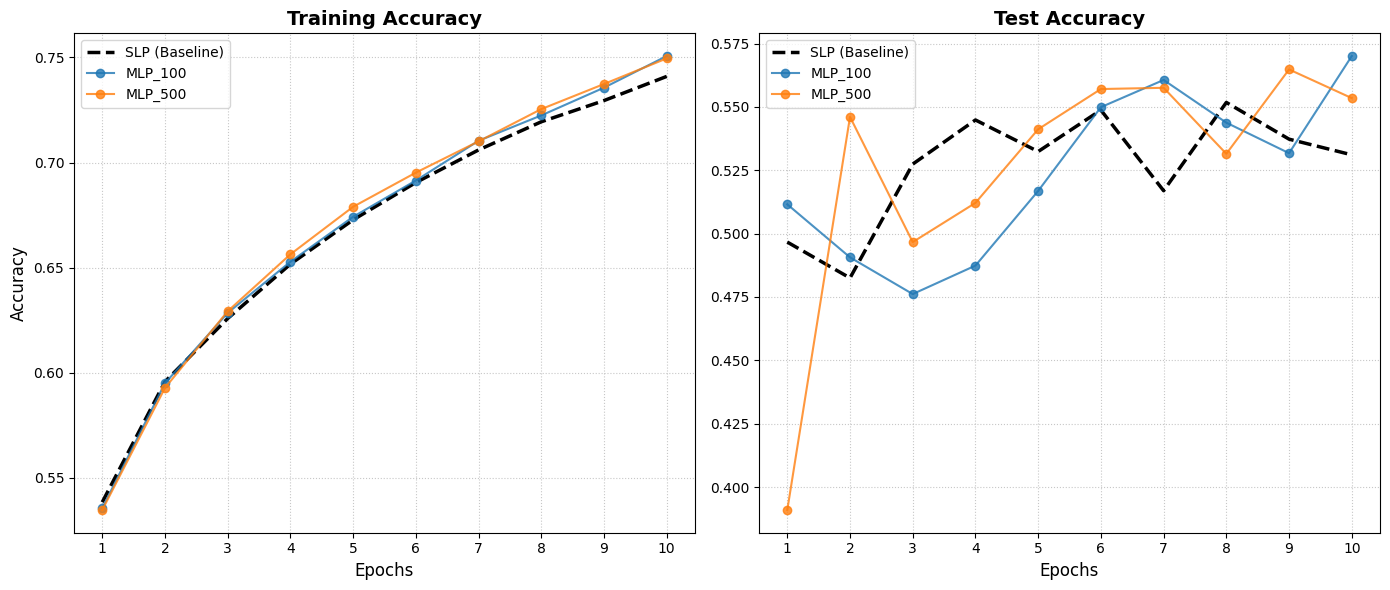

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
epochs_range = range(1, EPOCHS + 1)


for model_name, metrics in experiment_results.items():
    train_accs = metrics['train']
    test_accs = metrics['test']

    if model_name == 'SLP':
        ax1.plot(epochs_range, train_accs, label=f"{model_name} (Baseline)", linestyle='--', color='black', linewidth=2.5)
        ax2.plot(epochs_range, test_accs, label=f"{model_name} (Baseline)", linestyle='--', color='black', linewidth=2.5)
    else:
        ax1.plot(epochs_range, train_accs, label=model_name, marker='o', alpha=0.8)
        ax2.plot(epochs_range, test_accs, label=model_name, marker='o', alpha=0.8)

ax1.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

ax2.set_title('Test Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()

plt.show()